In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
dataset = pd.read_csv("Dataset of Diabetes .csv")
dataset.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


# New section

In [3]:
# Generate a full summary of the dataset to review each column’s data type, non-null count, and overall structure
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [4]:
# Produce descriptive statistics for all numerical features to understand their distributions, ranges, and central tendencies
dataset.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [5]:
# Count the number of unique values in each column of the dataset
dataset.nunique()

ID           800
No_Pation    961
Gender         3
AGE           50
Urea         110
Cr           113
HbA1c        111
Chol          77
TG            69
HDL           48
LDL           65
VLDL          60
BMI           64
CLASS          5
dtype: int64

In [6]:
# Identify missing data by counting how many NaN values appear in each column of the dataset
dataset.isna().sum()

ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

In [7]:
# Display the distribution of the diabetes outcome classes to check for imbalance in the target variable
print('\nClass distribution:')
print(dataset['CLASS'].value_counts())

# The repeated class labels indicate inconsistent formatting in the dataset


Class distribution:
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64


In [8]:
# Clean up target labels
dataset['CLASS'] = dataset['CLASS'].astype(str).str.strip().str.upper()

In [9]:
# Display class distribution
print('\nClass distribution:')
print(dataset['CLASS'].value_counts())


Class distribution:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


In [10]:
# Display class distribution
print('\nClass distribution:')
print(dataset['Gender'].value_counts())


Class distribution:
Gender
M    565
F    434
f      1
Name: count, dtype: int64


In [11]:
# Clean up target labels
dataset['Gender'] = dataset['Gender'].astype(str).str.strip().str.upper()

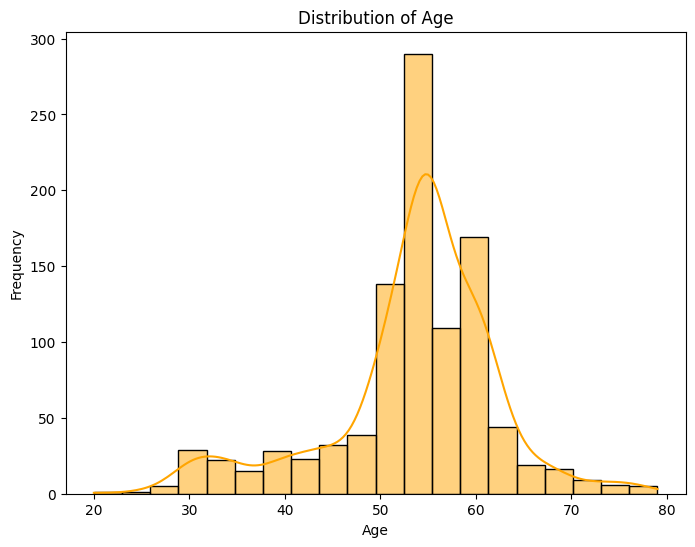

In [12]:
# Visualize age distribution
plt.figure(figsize=(8, 6))
sns.histplot(dataset['AGE'], bins=20, kde=True, color='orange')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

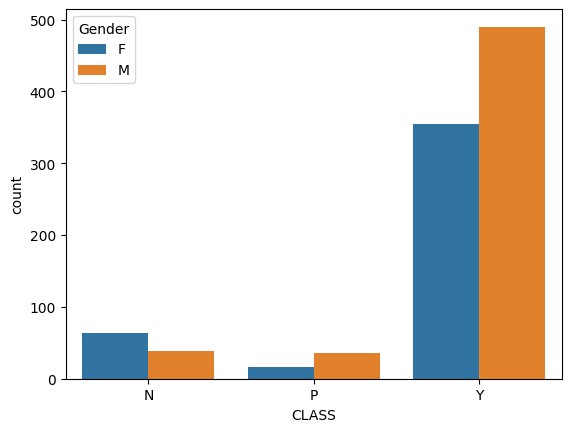

In [13]:
ax = sns.countplot(x='CLASS', hue='Gender', data=dataset)

plt.show()

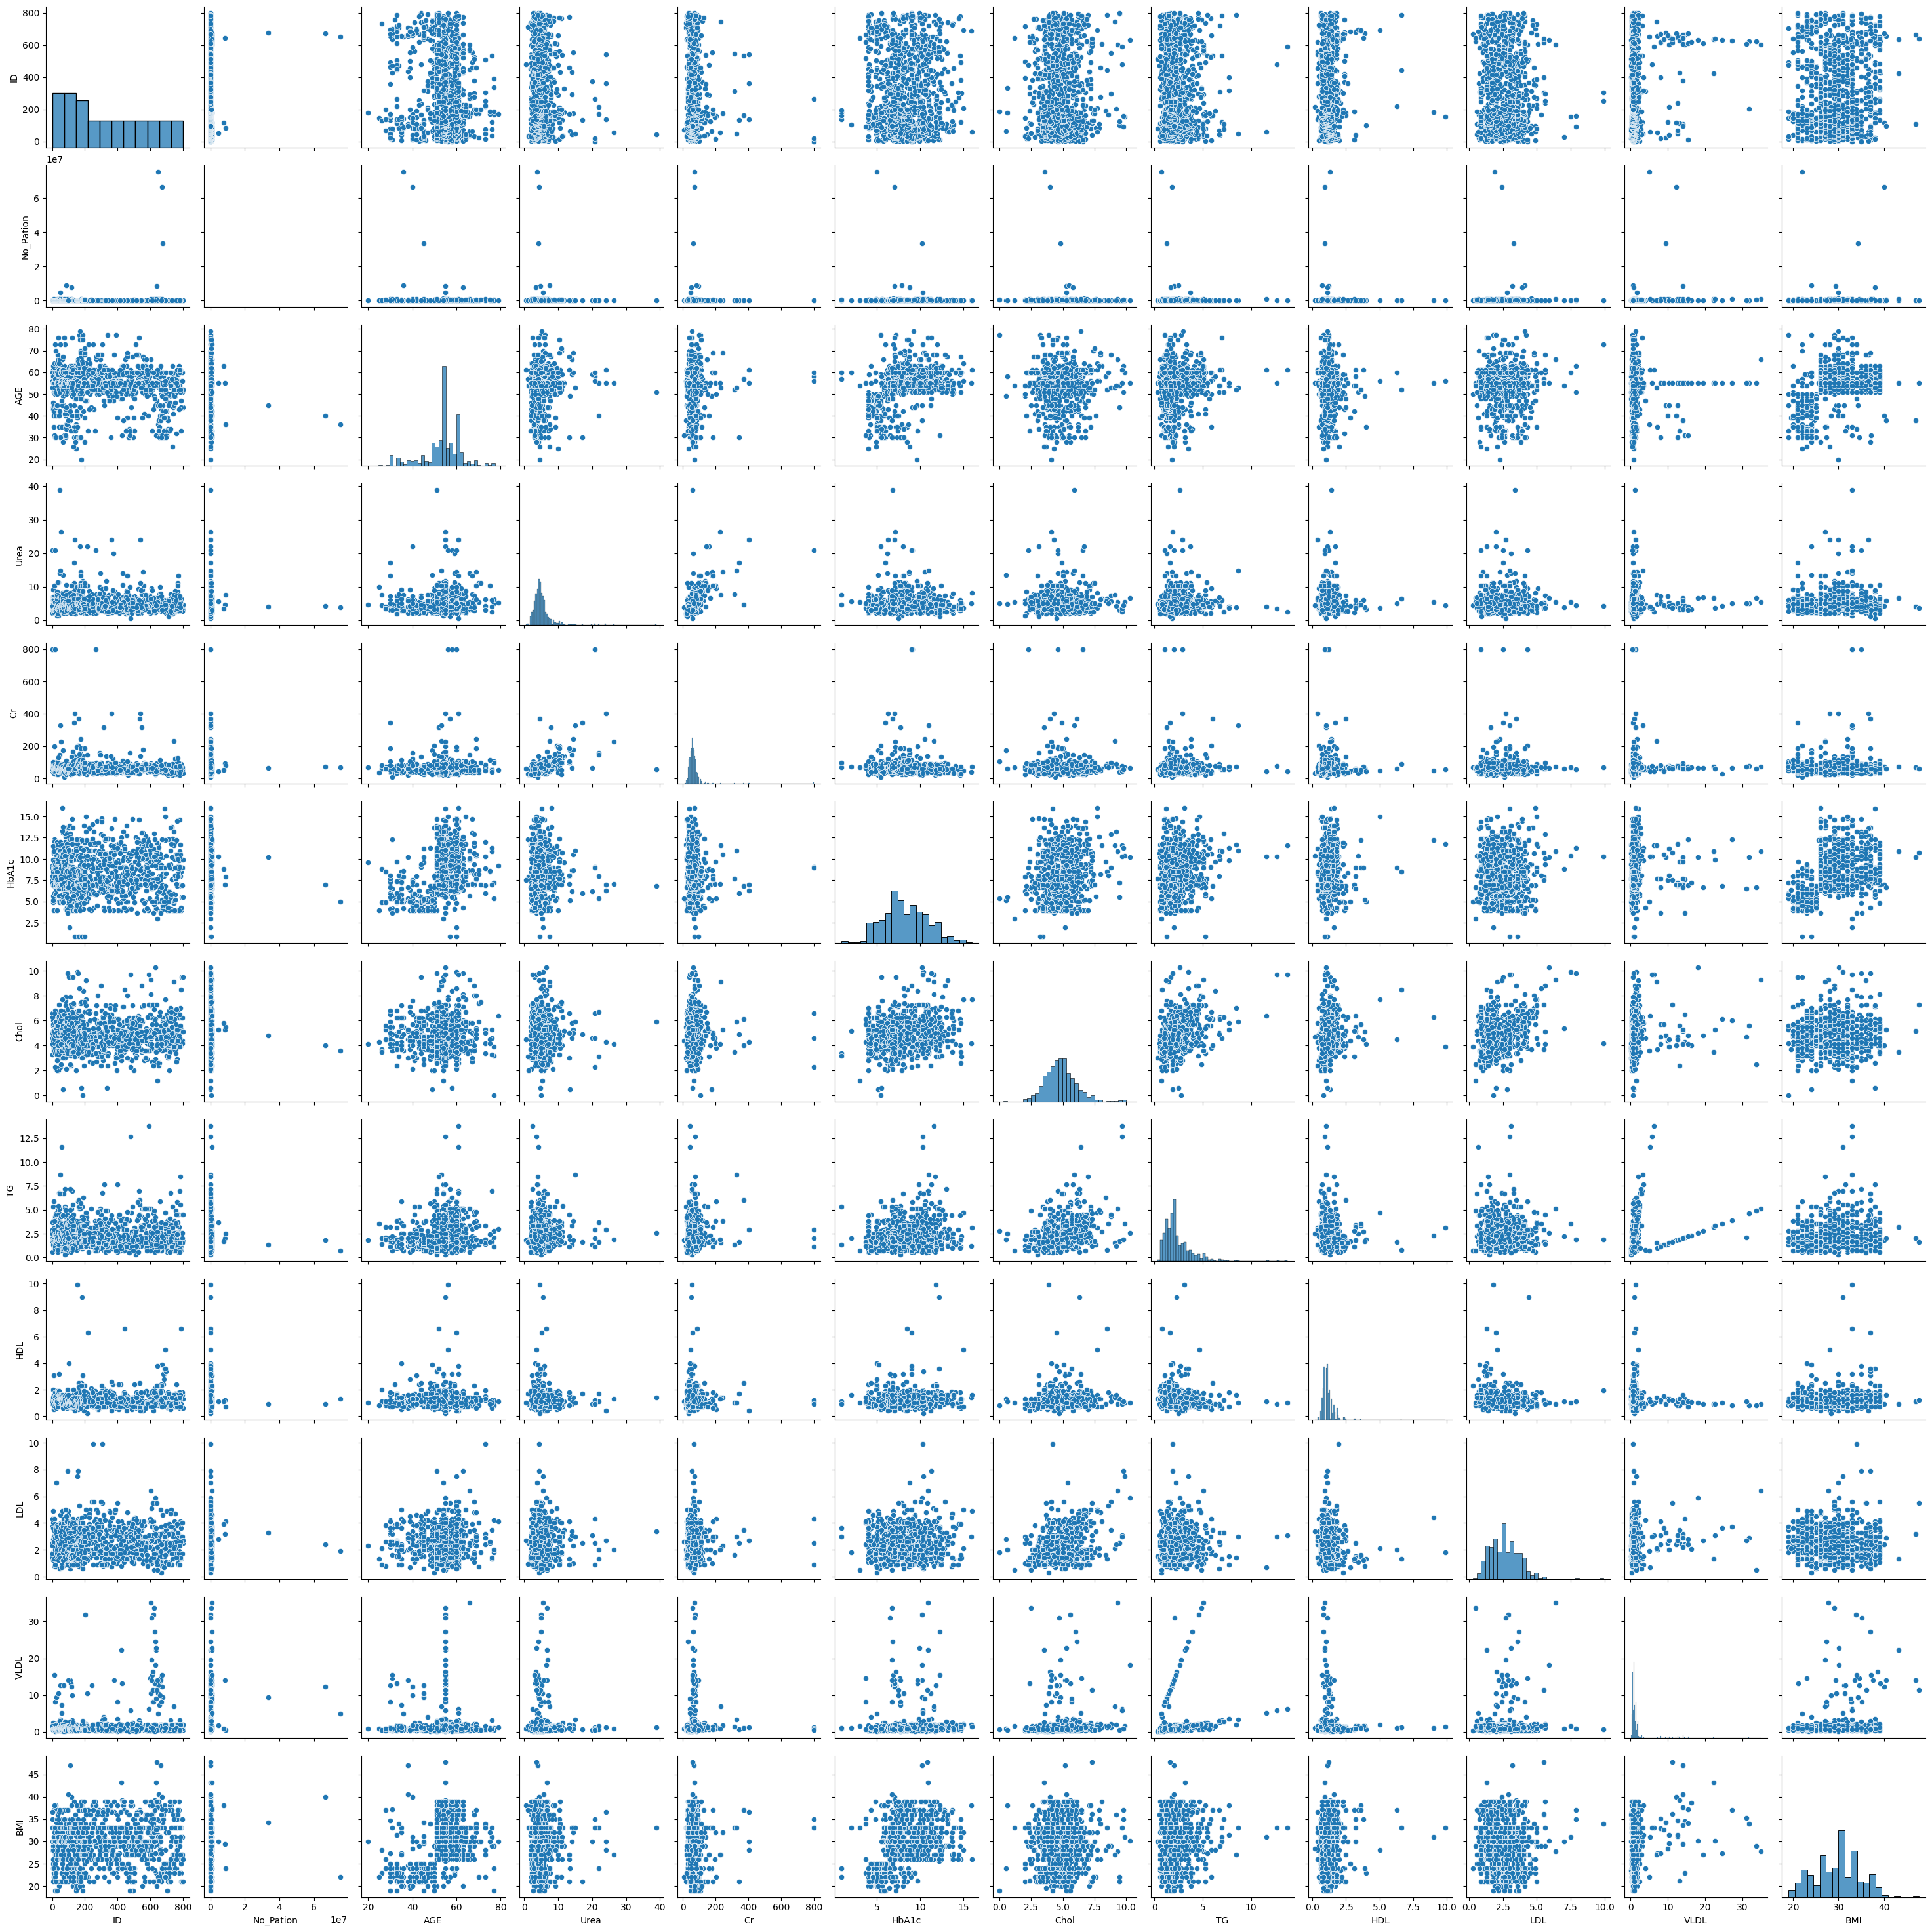

In [14]:
sns.pairplot(dataset)

In [15]:
dataset.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


In [16]:
# Identify all categorical (object-type) columns in the dataset for encoding
cat_columns = dataset.select_dtypes(['object']).columns

# Convert each categorical column into numeric codes using factorization
dataset[cat_columns] = dataset[cat_columns].apply(lambda x: pd.factorize(x)[0])

# Display the first two rows to confirm that categorical features were successfully encoded
dataset.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,735,34221,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0


In [17]:
# Create the feature matrix (X) by removing the target label (CLASS) and non-predictive identifiers (ID, No_Pation)
X = dataset.drop(columns=['CLASS', 'ID', 'No_Pation'])

# Extract the diabetes classification labels into the target vector (y)
y = dataset['CLASS']

# Display the first few rows of the feature matrix
X.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0


In [18]:
# Apply standardization to the feature set so all medical measurements share a comparable scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Preview the standardized feature matrix
X_scaled.head(2)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,-1.139671,-0.401144,-0.144781,-0.382672,-1.334983,-0.509436,-1.035084,1.810756,-1.085457,-0.369958,-1.124622
1,0.877446,-3.130017,-0.212954,-0.115804,-1.334983,-0.893730,-0.678063,-0.158692,-0.457398,-0.342649,-1.326239


In [19]:
# First split: divide the dataset into an 80% training+validation set and a 20% test set,
# ensuring class proportions are preserved with stratified sampling
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate the training+validation set into 60% training and 20% validation,
# maintaining overall class balance across all subsets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Display the combined training and validation feature set
X_train_val

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
678,0,56,2.3,22,10.2,5.8,2.0,1.1,1.8,0.9,27.00
186,1,30,4.8,80,5.5,5.5,1.8,1.2,3.5,0.8,25.00
327,1,63,4.9,65,7.8,3.6,1.1,1.0,2.1,0.5,33.00
574,1,67,7.8,99,7.1,2.7,1.0,0.8,1.4,0.5,29.63
748,1,60,7.5,83,7.6,4.6,4.6,0.6,2.7,1.4,33.00
...,...,...,...,...,...,...,...,...,...,...,...
280,1,55,3.8,46,6.0,4.3,1.5,1.0,2.6,0.7,35.00
228,1,56,3.4,44,4.8,4.1,1.5,0.8,1.7,1.4,39.00
385,1,55,3.7,93,7.2,3.2,1.9,0.6,1.8,0.8,31.00
904,0,55,4.5,42,9.4,3.8,0.9,1.5,2.0,0.2,30.00


In [20]:
# Using the combined train+val set since GridSearchCV handles its own validation internally
X_grid = X_train_val
y_grid = y_train_val

# Create a pipeline that first normalizes the data, then applies SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),    # Apply feature scaling
    ('svm', SVC())                   # SVM model
])

# Parameter options that will be tested during the grid search
param_grid = {
    'svm__C': [0.1, 1, 10],           # Regularization values to try
    'svm__kernel': ['linear', 'rbf'], # Kernel types to compare
    'svm__gamma': ['scale', 'auto']   # Gamma settings for RBF kernel
}

# Perform the grid search with 5-fold CV to find the best setup
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the search on the training+validation portion
grid_search.fit(X_grid, y_grid)

# Display the best settings found and their CV accuracy
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Test the optimized model on the separate test split
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Show test accuracy plus detailed class results
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Best parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best cross-validation accuracy: 0.94375
Test Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        21
           1       0.71      0.50      0.59        10
           2       0.98      0.99      0.98       169

    accuracy                           0.95       200
   macro avg       0.84      0.78      0.80       200
weighted avg       0.95      0.95      0.95       200



In [21]:
# Confusion matrix and performance metrics
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 18   1   2]
 [  3   5   2]
 [  1   1 167]]


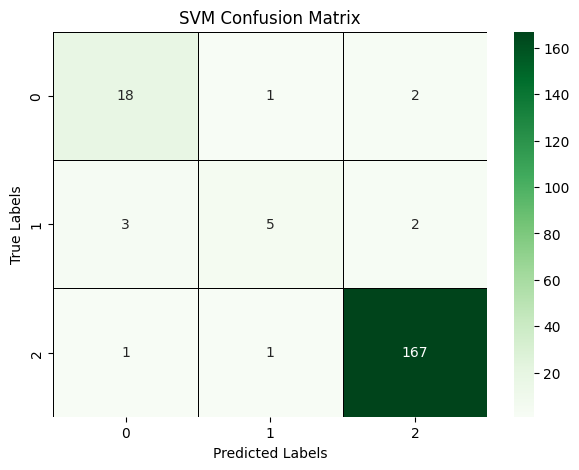

In [22]:
# Create a heatmap for the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black')

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Confusion Matrix')

# Display the plot
plt.show()


In [23]:
# Train a Decision Tree using Entropy
# Build a Decision Tree with simple depth and leaf settings to reduce overfitting
clf = DecisionTreeClassifier(criterion = "entropy", random_state = 42,max_depth = 3, min_samples_leaf = 5)
# Fit the model on the training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [24]:
# Evaluate the Decision Tree on the Test Set
# Predictions on the test data
y_pred = clf.predict(X_test)

# Compute accuracy and classification metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Confusion Matrix:
 [[ 18   0   3]
 [  0   9   1]
 [  0   3 166]]
Accuracy: 0.965
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92        21
           1       0.75      0.90      0.82        10
           2       0.98      0.98      0.98       169

    accuracy                           0.96       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.97      0.96      0.97       200



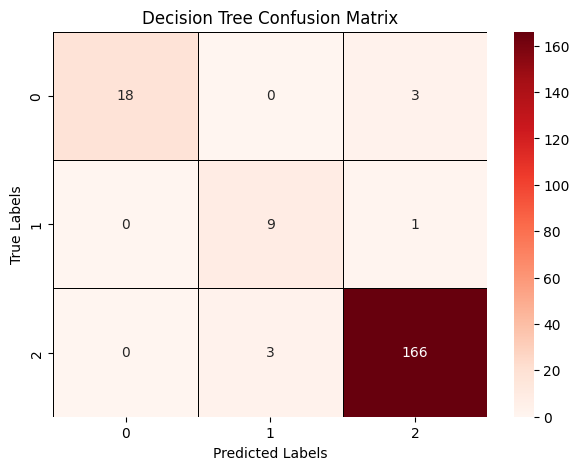

In [25]:
# Visualize Confusion Matrix
# Create a heatmap for the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=0.5, linecolor='black')

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Decision Tree Confusion Matrix')

# Display the plot
plt.show()


Training set size: 600 samples
Validation set size: 200 samples
Testing set size: 200 samples
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best hyperparameters found via GridSearchCV: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1}

Accuracy of the best model on the test set: 0.99


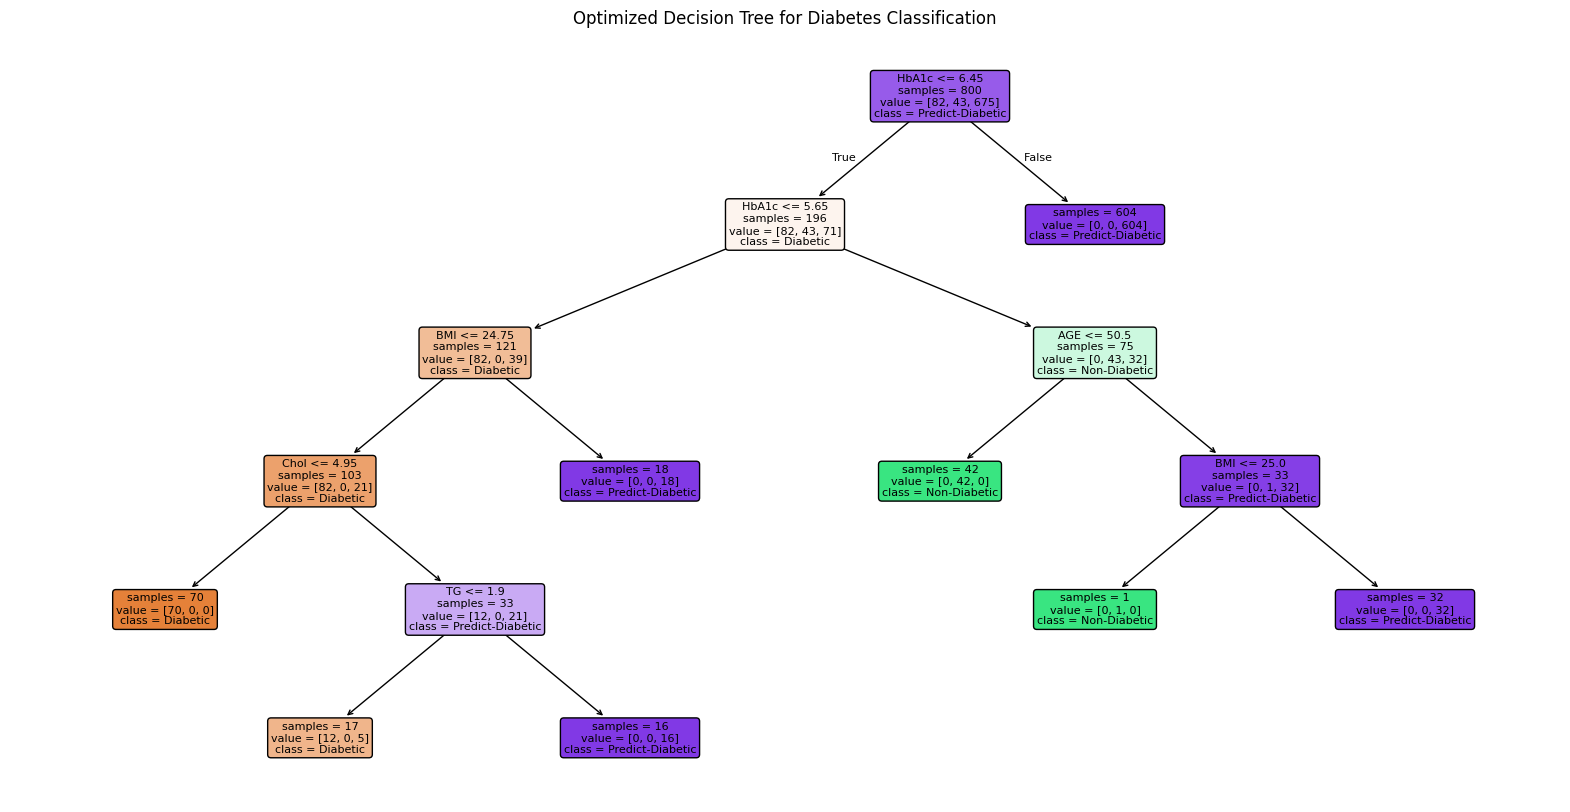

In [26]:
# Split Data into Train, Validation, and Test Sets

# Standard split: 80% train, 10% validation, 10% test
# (Split already done earlier – here we only display the sizes

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Testing set size: {len(X_test)} samples")


#Tune Hyperparameters to Reduce Overfitting

# Overfitting occurs when the model learns the training data too well, including its noise.
# Use GridSearchCV to try different parameters and pick the best one

# Key parameters for preventing overfitting in Decision Trees:
#   - max_depth: Limits how deep the tree can grow. A smaller value reduces complexity.
#   - min_samples_leaf: Minimum number of samples required to be at a leaf node.
#   - ccp_alpha: Cost-complexity pruning parameter. A higher value leads to more pruning.

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Base Decision Tree estimator
dt_base = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV using 5-fold cross validation
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_val, y_train_val)

# Print the best parameters found
best_params = grid_search.best_params_
print(f"\nBest hyperparameters found via GridSearchCV: {best_params}")


# Train Final Decision Tree with Best Parameters
best_dt_model = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    criterion=best_params['criterion'],
    random_state=42)

best_dt_model.fit(X_train_val, y_train_val)


# Evaluate the Optimized Model
# Test the tuned model on unseen data.
y_pred = best_dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the best model on the test set: {accuracy:.2f}")

# Visualize the Optimized Decision Tree
# Display the pruned tree structure with colors and labels.
plt.figure(figsize=(20, 10))
plot_tree(best_dt_model,
          feature_names=X.columns,
          class_names=['Diabetic', 'Non-Diabetic', 'Predict-Diabetic'],
          filled=True,
          rounded=True,
          fontsize=8,
          impurity=False)
plt.title("Optimized Decision Tree for Diabetes Classification")
plt.show()


In [27]:
# Train K-Nearest Neighbors Model
# Use KNN with k = 9 neighbors
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_val, y_train_val)

KNeighborsClassifier(n_neighbors=9)

In [28]:
# Evaluate KNN on the Test Set
# Predictions on the test set
y_pred_knn = knn.predict(X_test)

# Confusion matrix and performance metrics
cm = confusion_matrix(y_test, y_pred_knn)
accuracy = accuracy_score(y_test, y_pred_knn)
report = classification_report(y_test, y_pred_knn)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Confusion Matrix:
 [[ 13   0   8]
 [  5   3   2]
 [  3   0 166]]
Accuracy: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.62      0.62        21
           1       1.00      0.30      0.46        10
           2       0.94      0.98      0.96       169

    accuracy                           0.91       200
   macro avg       0.85      0.63      0.68       200
weighted avg       0.91      0.91      0.90       200



Accuracy: 0.91


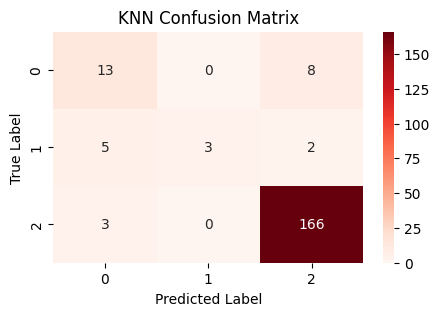

In [29]:
# Visualize KNN Confusion Matrix

# predictions on the test data
y_pred_knn = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()